# 0. Libraries

In [19]:
# pip install pandas openpyxl

In [ ]:
import pandas as pd
import os, openpyxl

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from scipy.stats import ks_2samp

# 1. Load Dataset

## 1.1. 경로 설정

In [21]:
print(os.getcwd())

c:\workspace\26KAMP


In [22]:
os.chdir("c:/workspace/26KAMP")

In [23]:
print(os.getcwd())

c:\workspace\26KAMP


## 1.2. 데이터 불러오기 및 구조 확인

In [24]:
cn7_l = pd.read_csv('./data/origin/moldset_labeled_cn7.csv', encoding='cp949')

In [25]:
cn7_l.shape

(1211, 26)

In [26]:
cn7_l.head(10)

,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
0,0,0,1.679123,1.491397,-0.478017,0.361047,0.978580,-0.711164,1.532018,0.0,...,-0.533773,0.729073,-1.598068,-0.672350,-1.536620,0.008133,-1.352970,-1.780463,1.023094,1.287574
1,1,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0.0,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
2,2,0,2.080358,1.894372,-0.527100,1.886261,0.978580,-0.711164,1.471608,0.0,...,-0.533773,0.056153,0.622557,0.914107,0.504051,-0.915098,-2.263700,-0.874018,1.023094,1.337339
3,3,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0.0,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
4,4,0,1.679123,1.894372,-0.527100,1.377857,0.978580,1.202502,1.471608,0.0,...,-0.533773,0.729073,-0.765355,1.231418,0.886706,-0.299626,0.013158,-1.176164,1.166162,1.337339
5,5,0,1.277888,1.088442,-0.576184,1.886261,0.978580,-0.711164,1.471608,0.0,...,-0.152634,0.280414,0.067358,0.596893,1.269321,0.008133,0.013158,-0.571865,1.166162,1.337339
6,6,0,1.277888,1.088442,-0.576184,1.886261,0.978580,-0.711164,1.471608,0.0,...,-0.152634,0.280414,0.067358,0.596893,1.269321,0.008133,0.013158,-0.571865,1.166162,1.337339
7,7,0,1.277888,1.088442,-0.478017,1.377857,0.978580,-0.711164,1.532018,0.0,...,-0.533773,-0.841164,0.344957,-0.037728,1.141770,0.008133,0.013158,-1.075448,1.166162,1.337339
8,8,0,1.277888,1.088442,-0.478017,1.377857,0.978580,-0.711164,1.532018,0.0,...,-0.533773,-0.841164,0.344957,-0.037728,1.141770,0.008133,0.013158,-1.075448,1.166162,1.337339
9,9,0,0.876653,0.685468,-0.527100,0.361047,2.859537,-0.711164,1.411244,0.0,...,-1.296037,-1.065425,-1.042954,-0.672350,0.504051,1.239076,0.468557,-1.377602,1.023094,1.287574


## 1.3. 컬럼 확인

In [27]:
cn7_l.columns

Index(['Unnamed: 0', 'PassOrFail', 'Injection_Time', 'Filling_Time',
       'Plasticizing_Time', 'Cycle_Time', 'Clamp_Close_Time',
       'Cushion_Position', 'Plasticizing_Position', 'Clamp_Open_Position',
       'Max_Injection_Speed', 'Max_Screw_RPM', 'Average_Screw_RPM',
       'Max_Injection_Pressure', 'Max_Switch_Over_Pressure',
       'Max_Back_Pressure', 'Average_Back_Pressure', 'Barrel_Temperature_1',
       'Barrel_Temperature_2', 'Barrel_Temperature_3', 'Barrel_Temperature_4',
       'Barrel_Temperature_5', 'Barrel_Temperature_6', 'Hopper_Temperature',
       'Mold_Temperature_3', 'Mold_Temperature_4'],
      dtype='str')

#### 가이드북 p.20 참고


* 'Unnamed: 0': 인덱스 번호

* 'PassOrFail': 사출되는 각 물품마다 검수자가 양품 선별을 하여 붙이는 레이블 값

* 'Injection_Time'(Sec (초)): 고압+사출시간(고압(사출압): 재료를 금형에 유입시킬때의 압력, 사출시간: 재료를 금형에 유입시키는데 소요되는 시간)

* 'Filling_Time'(Sec (초)): 충진시간으로 사출기에서 금형으로 내용물이 주입되는 시간

* 'Plasticizing_Time'(Sec (초)): 계량시간으로 재료를 스크류에 1번 생산할 만큼 용융되어 저장되는 시간

* 'Cycle_Time'(Sec (초)): 1번의 제품생산에 소요되는 생산시간

* 'Clamp_Close_Time'(Sec (초)): 제품이 생산되고 난후 열려있는 금형을 사출기가 닫아주고 빈틈이 없이 고정축과 이동축을 꽉 잡아주는데 걸리는 시간

* 'Cushion_Position'(mm): 보압(사출압의 다음으로 가해지는 압력(금형내부압력을 조절하여 과충전을방지))을 하기위한 스크류의 위치

* 'Plasticizing_Position'(mm): 계량완료위치(계량을 마친 스크류의 위치)

* 'Clamp_Open_Position'(mm): 제품이 생산되어 추출하기위해 금형이 열리고 난 위치

* 'Max_Injection_Speed'(mm/s): 배럴에 계량되어 있는 용융수지가 금형으로 흘러들어가는데 측정되는 최대 속도

* 'Max_Screw_RPM'(mm/s): 사출을 위한 스크류의 최대속도

* 'Average_Screw_RPM'(mm/s): 사출을 위한 스크류의 평균속도

* 'Max_Injection_Pressure'(MPa): 배럴에 계량되어 있는 용융수지가 금형으로 흘러들어가는데 가해지는 최대 압력

* 'Max_Switch_Over_Pressure'(MPa): 사출에서 보압(충진된 수지가 밀리지않게 압력을준다)으로 변환되는 압력

* 'Max_Back_Pressure'(MPa): 수지가 계량이 되는중에 스크류가 밀려나는 현상을 저지하기위한 최대압력

* 'Average_Back_Pressure'(MPa): 수지가 계량이 되는중에 스크류가 밀려나는 현상을 저지하기위한 평균압력

* 'Barrel_Temperature_1~6'(섭씨 (°C)): 계량 및 사출시 수지가 일정하게 용융(녹임)을 유지하기위해 온도가 일정해야한다

* 'Hopper_Temperature'(섭씨 (°C)): 재료주입구의 온도(충분히 건조시켜주며 재료가 용융되는시간을 절약시켜 주기위해 온도가 높아야한다)

* 'Mold_Temperature_3, 4'(섭씨 (°C)): 재료주입구의 온도(충분히 건조시켜주며 재료가 용융되는시간을 절약시켜 주기위해 온도가 높아야한다)

# 2. EDA

## 2.1. 통계량 확인

In [28]:
cn7_l.describe()

,Unnamed: 0,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,1211.000000,1211.000000,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1211.0,...,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03
mean,605.000000,0.014038,-2.957172e-14,-5.351073e-15,6.477615e-15,5.069438e-14,-1.574811e-14,4.630532e-12,-3.628403e-14,0.0,...,-3.708200e-15,-1.824763e-14,-3.505481e-14,8.745367e-15,2.114319e-14,5.257195e-15,-3.579410e-14,-2.675537e-15,-8.214367e-16,-1.642873e-16
std,349.729896,0.117696,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,0.0,...,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00
min,0.000000,0.000000,-7.549091e+00,-7.776799e+00,-7.234252e-01,-3.706092e+00,-9.024657e-01,-2.613163e+00,-2.876962e+00,0.0,...,-6.631852e+00,-2.635662e+00,-2.985979e+00,-2.893331e+00,-2.046826e+00,-4.607976e+00,-2.719099e+00,-2.082616e+00,-1.909796e+00,-1.648589e+00
25%,302.500000,0.000000,-7.282486e-01,-5.234162e-01,-3.798495e-01,-6.557617e-01,-9.024657e-01,-7.111644e-01,-7.026540e-01,0.0,...,-5.337734e-01,-6.168347e-01,-7.653547e-01,-3.550389e-01,-8.989006e-01,-6.073388e-01,-8.975711e-01,-8.740180e-01,-7.652542e-01,-7.528108e-01
50%,605.000000,0.000000,-3.270136e-01,-1.204612e-01,-3.627368e-02,3.610475e-01,-9.024657e-01,-7.111644e-01,-6.422898e-01,0.0,...,2.284901e-01,5.615323e-02,6.735821e-02,-3.772821e-02,-6.117000e-03,8.132912e-03,1.315810e-02,-1.689960e-01,9.315350e-02,-1.556248e-01
75%,907.500000,0.000000,8.766531e-01,6.854681e-01,2.091349e-01,3.610475e-01,9.785804e-01,1.202502e+00,1.471608e+00,0.0,...,6.096146e-01,7.290727e-01,6.225566e-01,5.968932e-01,8.867055e-01,6.236047e-01,4.685574e-01,7.374564e-01,1.094628e+00,1.287574e+00
max,1210.000000,1.000000,2.080358e+00,2.297327e+00,2.003846e+01,1.256247e+01,2.859537e+00,6.943503e+00,1.592429e+00,0.0,...,1.753017e+00,3.196558e+00,3.398379e+00,3.135185e+00,2.544760e+00,3.393298e+00,2.745415e+00,2.550354e+00,1.380764e+00,1.436870e+00


In [29]:
cn7_l = cn7_l.drop(columns = ['Unnamed: 0'])

In [30]:
cn7_l.describe()

,PassOrFail,Injection_Time,Filling_Time,Plasticizing_Time,Cycle_Time,Clamp_Close_Time,Cushion_Position,Plasticizing_Position,Clamp_Open_Position,Max_Injection_Speed,...,Average_Back_Pressure,Barrel_Temperature_1,Barrel_Temperature_2,Barrel_Temperature_3,Barrel_Temperature_4,Barrel_Temperature_5,Barrel_Temperature_6,Hopper_Temperature,Mold_Temperature_3,Mold_Temperature_4
count,1211.000000,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1211.0,1.211000e+03,...,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03,1.211000e+03
mean,0.014038,-2.957172e-14,-5.351073e-15,6.477615e-15,5.069438e-14,-1.574811e-14,4.630532e-12,-3.628403e-14,0.0,3.238808e-15,...,-3.708200e-15,-1.824763e-14,-3.505481e-14,8.745367e-15,2.114319e-14,5.257195e-15,-3.579410e-14,-2.675537e-15,-8.214367e-16,-1.642873e-16
std,0.117696,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,0.0,1.000413e+00,...,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00,1.000413e+00
min,0.000000,-7.549091e+00,-7.776799e+00,-7.234252e-01,-3.706092e+00,-9.024657e-01,-2.613163e+00,-2.876962e+00,0.0,-1.541785e+00,...,-6.631852e+00,-2.635662e+00,-2.985979e+00,-2.893331e+00,-2.046826e+00,-4.607976e+00,-2.719099e+00,-2.082616e+00,-1.909796e+00,-1.648589e+00
25%,0.000000,-7.282486e-01,-5.234162e-01,-3.798495e-01,-6.557617e-01,-9.024657e-01,-7.111644e-01,-7.026540e-01,0.0,-5.683212e-01,...,-5.337734e-01,-6.168347e-01,-7.653547e-01,-3.550389e-01,-8.989006e-01,-6.073388e-01,-8.975711e-01,-8.740180e-01,-7.652542e-01,-7.528108e-01
50%,0.000000,-3.270136e-01,-1.204612e-01,-3.627368e-02,3.610475e-01,-9.024657e-01,-7.111644e-01,-6.422898e-01,0.0,1.575557e-02,...,2.284901e-01,5.615323e-02,6.735821e-02,-3.772821e-02,-6.117000e-03,8.132912e-03,1.315810e-02,-1.689960e-01,9.315350e-02,-1.556248e-01
75%,0.000000,8.766531e-01,6.854681e-01,2.091349e-01,3.610475e-01,9.785804e-01,1.202502e+00,1.471608e+00,0.0,4.051426e-01,...,6.096146e-01,7.290727e-01,6.225566e-01,5.968932e-01,8.867055e-01,6.236047e-01,4.685574e-01,7.374564e-01,1.094628e+00,1.287574e+00
max,1.000000,2.080358e+00,2.297327e+00,2.003846e+01,1.256247e+01,2.859537e+00,6.943503e+00,1.592429e+00,0.0,9.555703e+00,...,1.753017e+00,3.196558e+00,3.398379e+00,3.135185e+00,2.544760e+00,3.393298e+00,2.745415e+00,2.550354e+00,1.380764e+00,1.436870e+00


In [31]:
# 종속변수 & 독립변수 분리

cn7_l_y = cn7_l['PassOrFail']
cn7_l_x = cn7_l.drop(columns = ['PassOrFail'])

## 2.2. 데이터 중복 확인

* 중복 삭제 근거: 보수적으로 접근 -> 동일 레코드에 대해 한 경우에만 불량이 발생한 경우 잠재적으로 불량이 발생할 가능성이 있다고 간주하여 정상 데이터를 삭제

In [37]:
temp = cn7_l_x.copy()
temp["PassOrFail"] = cn7_l_y


# 불량(1)이 먼저 오도록 정렬
temp = temp.sort_values(
    by="PassOrFail",
    ascending=False
)

# 독립변수가 동일한 경우
# 불량을 우선적으로 하나만 남김
temp_dedup = temp.drop_duplicates(
    subset=cn7_l_x.columns.tolist(),
    keep="first"
)

# 원래 index 기준으로 정렬
temp_dedup = temp_dedup.sort_index()

cn7_l_x = temp_dedup.drop(columns="PassOrFail")
cn7_l_y = temp_dedup["PassOrFail"]

## 2.3. 컬럼별 데이터 확인

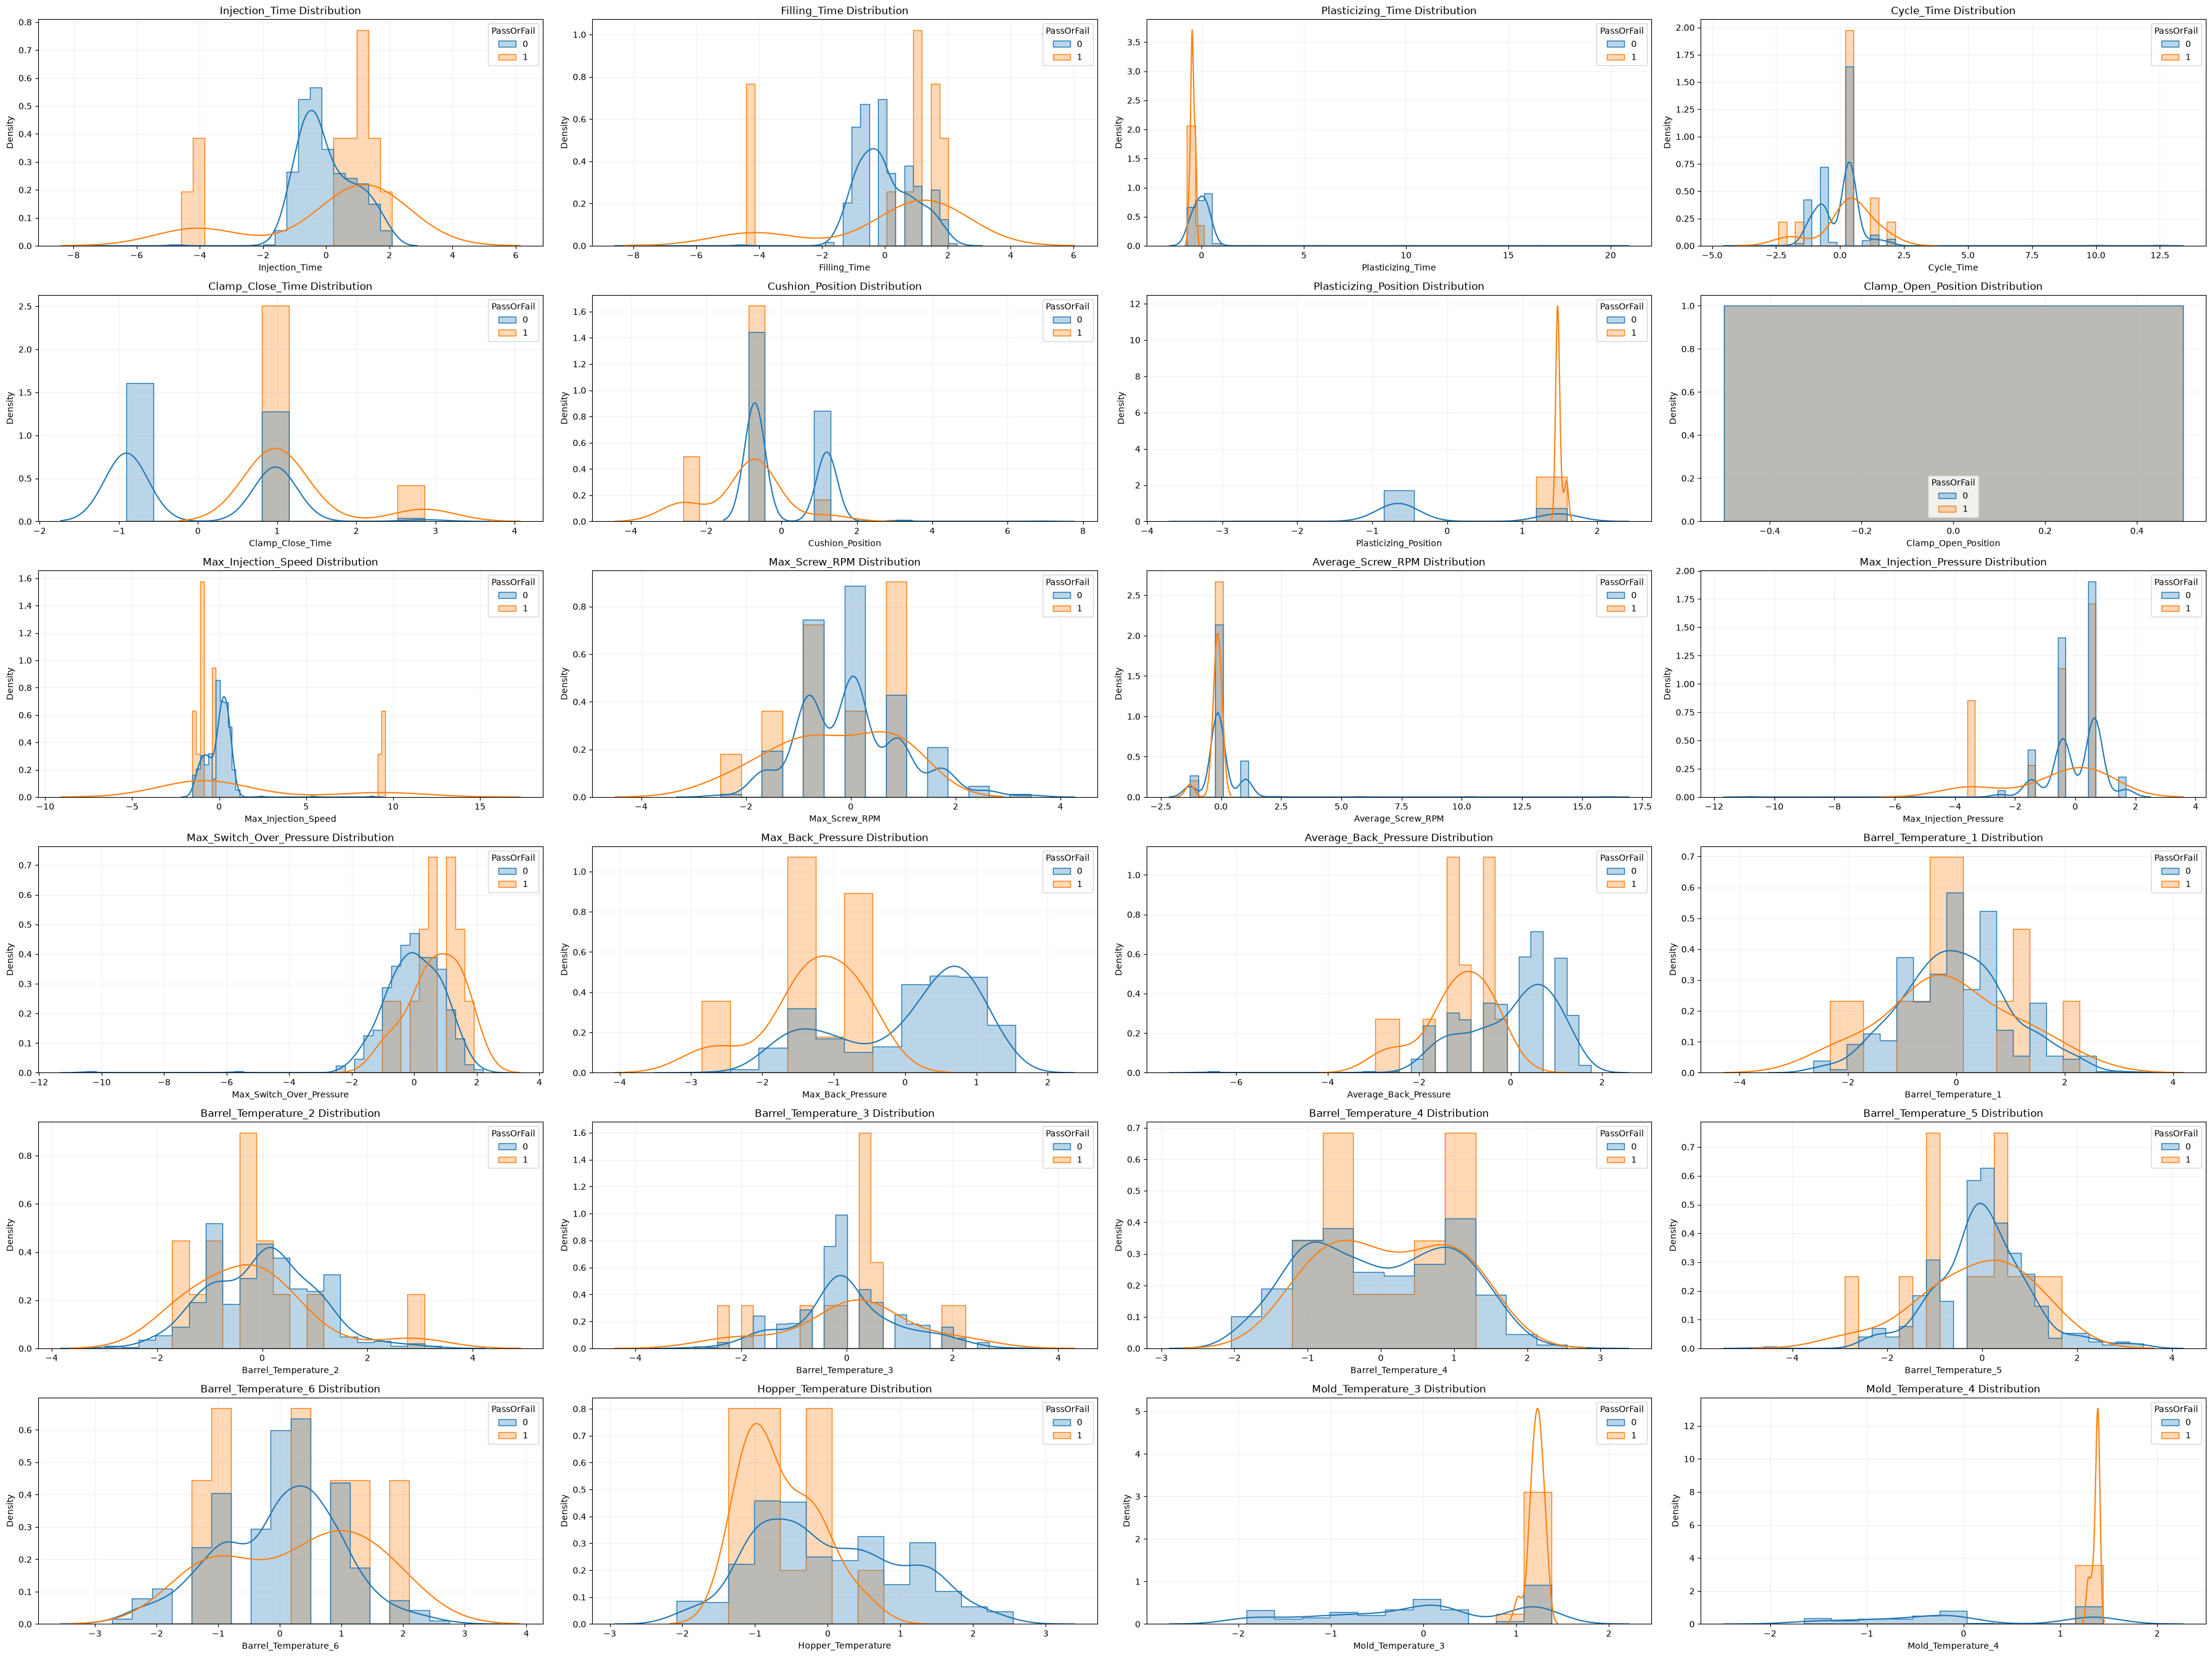

In [ ]:



plot_df = cn7_l_x.copy()
plot_df["PassOrFail"] = cn7_l_y.values

# 숫자형 변수만 선택
numeric_cols = cn7_l_x.select_dtypes(include="number").columns

# 그래프 설정
n_cols = 4
n_rows = math.ceil(len(numeric_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(36, 4.5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):

    ax = axes[i]

    # -------------------------
    # 1. Histogram
    # -------------------------
    sns.histplot(
        data=plot_df,
        x=col,
        hue="PassOrFail",
        stat="density",
        common_norm=False,
        element="step",
        alpha=0.3,
        kde=False,          # KDE는 따로 처리
        ax=ax
    )

    # -------------------------
    # 2. 클래스별 KDE
    # -------------------------
    for label in plot_df["PassOrFail"].dropna().unique():

        values = (
            plot_df.loc[
                plot_df["PassOrFail"] == label,
                col
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
        )

        # KDE가 가능한 경우만 수행
        if (
            len(values) >= 3
            and values.nunique() >= 2
            and values.std() > 1e-10
        ):
            try:
                sns.kdeplot(
                    x=values,
                    ax=ax,
                    label=f"{label} KDE"
                )
            except Exception:
                pass

    ax.set_title(f"{col} Distribution")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.grid(alpha=0.2)

# 남는 subplot 제거
for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [46]:
# KS 통계량 확인
# KS 통계량: 두 누적 분포 함수의 최대 거리 차이를 측정하는 비모수적 통계량

ks_results = []

numeric_cols = cn7_l_x.select_dtypes(include="number").columns

for col in numeric_cols:
    normal = cn7_l_x.loc[cn7_l_y == 0, col].dropna()
    abnormal = cn7_l_x.loc[cn7_l_y == 1, col].dropna()

    # 두 그룹 중 하나라도 데이터가 없으면 제외
    if len(normal) == 0 or len(abnormal) == 0:
        continue

    ks_stat, p_value = ks_2samp(
        normal,
        abnormal
    )

    ks_results.append({
        "Feature": col,
        "Normal_Median": normal.median(),
        "Abnormal_Median": abnormal.median(),
        "Normal_IQR": normal.quantile(0.75) - normal.quantile(0.25),
        "Abnormal_IQR": abnormal.quantile(0.75) - abnormal.quantile(0.25),
        "KS_Statistic": ks_stat,
        "P_Value": p_value,
        "Normal_Count": len(normal),
        "Abnormal_Count": len(abnormal)
    })

ks_df = (
    pd.DataFrame(ks_results)
    .sort_values("KS_Statistic", ascending=False)
    .reset_index(drop=True)
)

ks_df["Rank"] = ks_df.index + 1

ks_df = ks_df[
    [
        "Rank",
        "Feature",
        "KS_Statistic",
        "P_Value",
        "Normal_Median",
        "Abnormal_Median",
        "Normal_IQR",
        "Abnormal_IQR",
        "Normal_Count",
        "Abnormal_Count"
    ]
]

ks_df

,Rank,Feature,KS_Statistic,P_Value,Normal_Median,Abnormal_Median,Normal_IQR,Abnormal_IQR,Normal_Count,Abnormal_Count
0,1,Plasticizing_Position,0.758446,1.203054e-08,-0.642290,1.471608,2.113898,0.000000,592,14
1,2,Mold_Temperature_4,0.721284,1.043296e-07,-0.155625,1.387105,2.090150,0.037324,592,14
2,3,Mold_Temperature_3,0.711149,1.808727e-07,0.093154,1.237697,1.859882,0.071534,592,14
3,4,Max_Back_Pressure,0.706081,2.367974e-07,0.314806,-1.268531,1.759268,0.703710,592,14
4,5,Plasticizing_Time,0.701014,3.088743e-07,-0.036274,-0.453475,0.588984,0.122709,592,14
5,6,Average_Back_Pressure,0.599180,3.277691e-05,0.228490,-1.105467,1.143388,0.762264,592,14
6,7,Clamp_Close_Time,0.548986,2.162755e-04,-0.902466,0.978580,1.881046,0.000000,592,14
7,8,Max_Injection_Speed,0.474903,2.371053e-03,0.015756,-0.957708,0.973464,0.584077,592,14
8,9,Filling_Time,0.450290,4.763608e-03,-0.120461,1.088442,1.208884,1.108146,592,14
9,10,Injection_Time,0.441120,6.122975e-03,-0.327014,1.077271,1.203705,0.802432,592,14


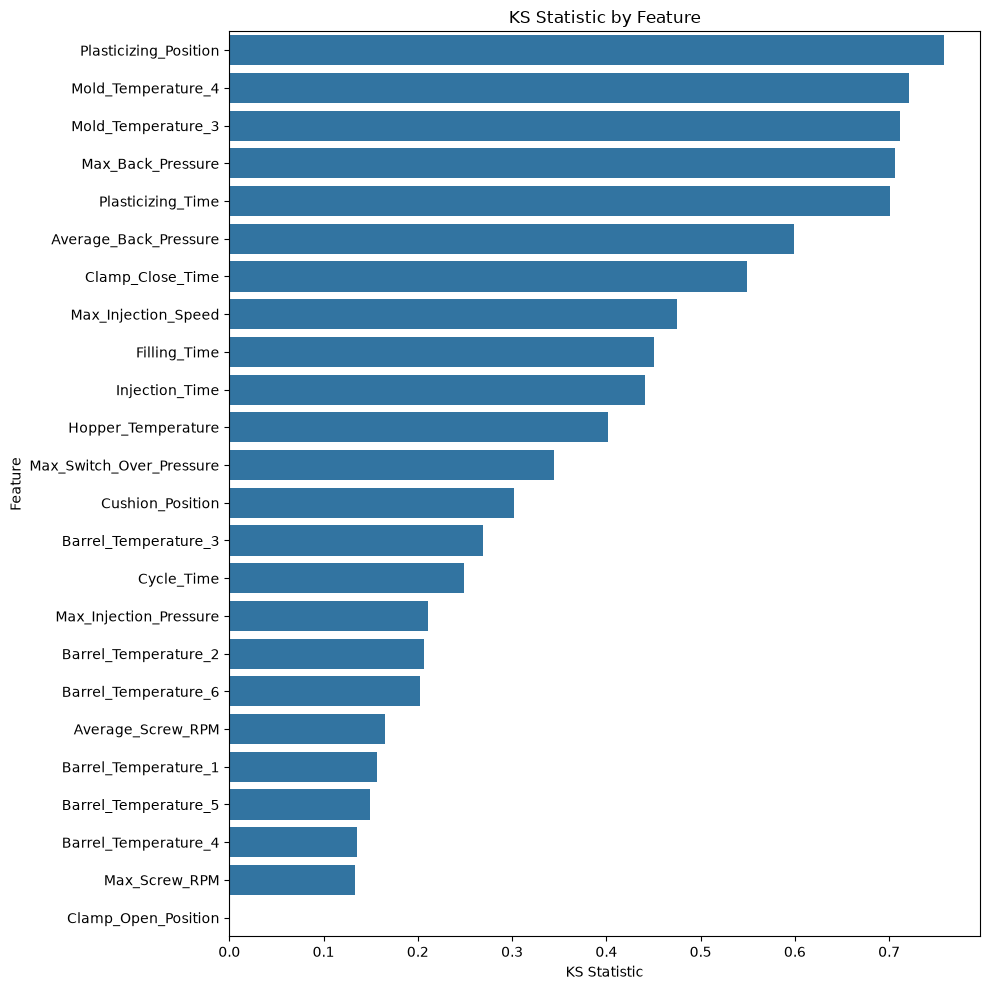

In [47]:
plt.figure(figsize=(10, 10))

sns.barplot(
    data=ks_df,
    x="KS_Statistic",
    y="Feature"
)

plt.title("KS Statistic by Feature")
plt.xlabel("KS Statistic")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

# 3. 양품·불량 공정조건 심화 EDA
분석 순서: **① 불량 유형 구분 → 기존 KS 상위 5개 변수의 10개 쌍 조합 → ② 개별 변수 분포와 사례 의존성 → ④ 공정 단계별 비교**.

기존 `cn7_l_x`, `cn7_l_y`, `ks_df`는 변경하지 않는다. 기존 KS 순위는 **동일 입력에서 불량 우선으로 한 행만 남긴 데이터**의 결과이므로, 원본 기록과 구분해서 해석한다. 아래에서는 CSV를 별도로 읽어 원본의 양품·불량 공존을 확인한다. 같은 24개 공정값을 하나의 패턴으로 정의하며 저장 인덱스는 시간으로 해석하지 않는다.

모든 공정값은 파일별 표준화 값이다. 분포·상관·관측 불량 비율은 탐색 결과이며 물리적 규격, 원인 또는 검증된 예측 성능을 뜻하지 않는다. 중복과 이산값이 많고 불량이 적으므로 KS는 분포 차이의 크기로 사용하고 p값으로 유의성을 판정하지 않는다.

In [18]:
from pathlib import Path
from itertools import combinations
from IPython.display import display, Markdown

eda3_root = next(p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / 'data/origin/moldset_labeled_cn7.csv').is_file())
eda3_raw = pd.read_csv(eda3_root / 'data/origin/moldset_labeled_cn7.csv')
eda3_features = [c for c in eda3_raw if c not in ['Unnamed: 0', 'PassOrFail']]
assert len(eda3_features) == 24
assert np.isfinite(eda3_raw[eda3_features].to_numpy()).all()
assert set(eda3_raw.PassOrFail.unique()) == {0, 1}
eda3_raw = eda3_raw.rename(columns={'Unnamed: 0': 'source_id'})
eda3_raw['pattern_id'] = pd.MultiIndex.from_frame(eda3_raw[eda3_features]).factorize(sort=False)[0]
eda3_patterns = eda3_raw.groupby('pattern_id').PassOrFail.agg(rows='size', defects='sum')
eda3_patterns['normal'] = eda3_patterns.rows - eda3_patterns.defects
eda3_patterns['type'] = np.select(
    [eda3_patterns.defects.eq(0), eda3_patterns.normal.eq(0)],
    ['normal_only', 'defect_only'], default='conflicting')
eda3_raw['pattern_type'] = eda3_raw.pattern_id.map(eda3_patterns['type'])
eda3_normal = eda3_raw[eda3_raw.PassOrFail.eq(0)].copy()
eda3_bad = eda3_raw[eda3_raw.PassOrFail.eq(1)].copy()
eda3_normal_unique = eda3_normal.drop_duplicates(eda3_features)
eda3_bad_unique = eda3_bad.drop_duplicates(eda3_features)
eda3_current = cn7_l_x.copy()
eda3_current['PassOrFail'] = cn7_l_y
eda3_top5 = ks_df.sort_values('Rank').head(5).Feature.tolist()
assert len(set(eda3_top5)) == 5

def eda3_say(text):
    display(Markdown(text))

eda3_colors = {'normal':'#3274A1', 'conflicting':'#E69F00', 'defect_only':'#CC3311'}
def eda3_scatter(ax, x, y):
    ax.scatter(eda3_normal_unique[x], eda3_normal_unique[y], s=20, alpha=.3,
               color=eda3_colors['normal'], label=f'Normal patterns (n={len(eda3_normal_unique)})')
    for kind, marker in [('conflicting','o'), ('defect_only','x')]:
        g = eda3_bad_unique[eda3_bad_unique.pattern_type.eq(kind)]
        kwargs = {'facecolors':'none','edgecolors':eda3_colors[kind]} if marker == 'o' else {'color':eda3_colors[kind]}
        ax.scatter(g[x], g[y], s=65, marker=marker, linewidths=1.5,
                   label=f'{kind} defects (n={len(g)})', **kwargs)
    ax.set(xlabel=x, ylabel=y)
    ax.grid(alpha=.15)
    ax.legend(fontsize=7)

display(ks_df.sort_values('Rank').head(5)[['Rank','Feature','KS_Statistic','Normal_Count','Abnormal_Count']])
eda3_say('**이번 조합 분석에 사용할 기존 KS 상위 5개:** ' + ', '.join(eda3_top5))

,Rank,Feature,KS_Statistic,Normal_Count,Abnormal_Count
0,1,Plasticizing_Position,0.758446,592,14
1,2,Mold_Temperature_4,0.721284,592,14
2,3,Mold_Temperature_3,0.711149,592,14
3,4,Max_Back_Pressure,0.706081,592,14
4,5,Plasticizing_Time,0.701014,592,14


**이번 조합 분석에 사용할 기존 KS 상위 5개:** Plasticizing_Position, Mold_Temperature_4, Mold_Temperature_3, Max_Back_Pressure, Plasticizing_Time

## 3.1 불량 유형 구분 ①
**질문:** 불량의 24개 공정값이 양품에서도 관측되는가?

`conflicting`은 같은 입력에 양품·불량이 모두 있는 패턴, `defect_only`는 현재 데이터에서 동일 입력의 양품이 없는 패턴이다. 후자가 제조상 불가능하거나 반드시 불량인 조건이라는 의미는 아니다. 행 수와 고유 패턴 수를 함께 센다.

,patterns,rows,normal_rows,defect_rows
type,,,,
conflicting,11,22,11,11
defect_only,3,6,0,6
normal_only,592,1183,1183,0


,source_id,pattern_id,pattern_type,same_input_normal_rows,same_input_defect_rows
47,47,24,conflicting,1,1
80,80,40,conflicting,1,1
95,95,48,conflicting,1,1
99,99,50,conflicting,1,1
101,101,51,conflicting,1,1
103,103,52,conflicting,1,1
105,105,53,conflicting,1,1
107,107,54,conflicting,1,1
109,109,55,conflicting,1,1
111,111,56,conflicting,1,1


,view,total,normal,defect
0,Original rows,1211,1194,17
1,Unique X + label,617,603,14
2,Existing defect-priority X,606,592,14


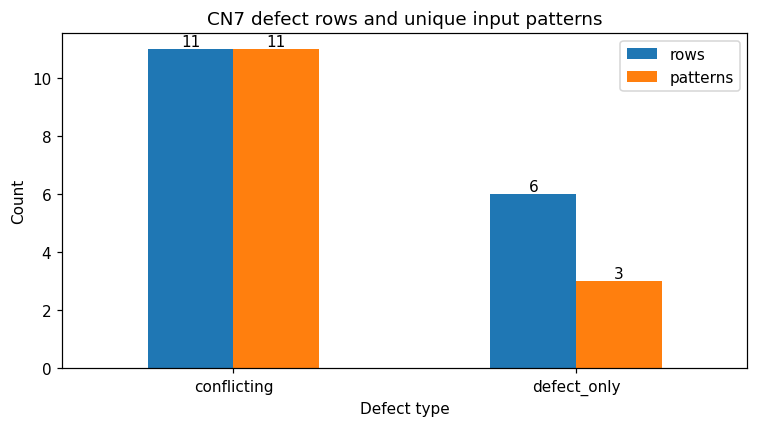

**결과:** 불량 17행 중 11행은 동일 입력의 양품이 존재한다. 나머지 6행의 ID는 [115, 116, 117, 118, 119, 120]이며 3개 고유 패턴이다. 기존 불량 우선 처리는 충돌 조건의 양품을 제거하므로 원본의 관측 불량률이나 분리 가능성과 동일하게 해석하지 않는다.

In [19]:
eda3_type_summary = eda3_patterns.groupby('type').agg(
    patterns=('rows','size'), rows=('rows','sum'), normal_rows=('normal','sum'), defect_rows=('defects','sum'))
display(eda3_type_summary)
eda3_bad_cases = eda3_bad[['source_id','pattern_id','pattern_type']].copy()
eda3_bad_cases['same_input_normal_rows'] = eda3_bad.pattern_id.map(eda3_patterns.normal)
eda3_bad_cases['same_input_defect_rows'] = eda3_bad.pattern_id.map(eda3_patterns.defects)
display(eda3_bad_cases)
display(pd.DataFrame([
    ['Original rows', len(eda3_raw), len(eda3_normal), len(eda3_bad)],
    ['Unique X + label', len(eda3_normal_unique)+len(eda3_bad_unique), len(eda3_normal_unique), len(eda3_bad_unique)],
    ['Existing defect-priority X', len(eda3_current), int(eda3_current.PassOrFail.eq(0).sum()), int(eda3_current.PassOrFail.eq(1).sum())]
], columns=['view','total','normal','defect']))
fig, ax = plt.subplots(figsize=(7,4))
eda3_bad.groupby('pattern_type').agg(rows=('pattern_id','size'), patterns=('pattern_id','nunique')).plot.bar(ax=ax, rot=0)
ax.set(title='CN7 defect rows and unique input patterns', ylabel='Count', xlabel='Defect type')
for container in ax.containers: ax.bar_label(container)
plt.tight_layout(); plt.show()
eda3_shared_n = int(eda3_bad.pattern_type.eq('conflicting').sum())
eda3_only_ids = eda3_bad.loc[eda3_bad.pattern_type.eq('defect_only'),'source_id'].tolist()
eda3_say(f'**결과:** 불량 {len(eda3_bad)}행 중 {eda3_shared_n}행은 동일 입력의 양품이 존재한다. '
         f'나머지 {len(eda3_bad)-eda3_shared_n}행의 ID는 {eda3_only_ids}이며 '
         f'{eda3_bad.loc[eda3_bad.pattern_type.eq("defect_only"),"pattern_id"].nunique()}개 고유 패턴이다. '
         '기존 불량 우선 처리는 충돌 조건의 양품을 제거하므로 원본의 관측 불량률이나 분리 가능성과 동일하게 해석하지 않는다.')

## 3.2 기존 KS 상위 5개 변수의 조합
**질문:** 상위 변수 두 개를 함께 보면 불량 조건을 더 구체적으로 설명할 수 있는가?

5개 변수의 **10개 쌍을 모두** 확인한다. 산점도는 중복 점의 영향을 줄이기 위해 라벨별 고유 전체입력 패턴을 사용한다. 주황색 빈 원은 양품과 입력이 같은 불량이라 파란 점 위에 겹칠 수 있다. 각 쌍의 동일 값 조합을 가진 양품 수와, 양품 고유 패턴에서의 Spearman 상관을 함께 확인한다. 정확한 조합이 드물다는 사실만으로 불량 위험이 높다고 판정하지 않는다.

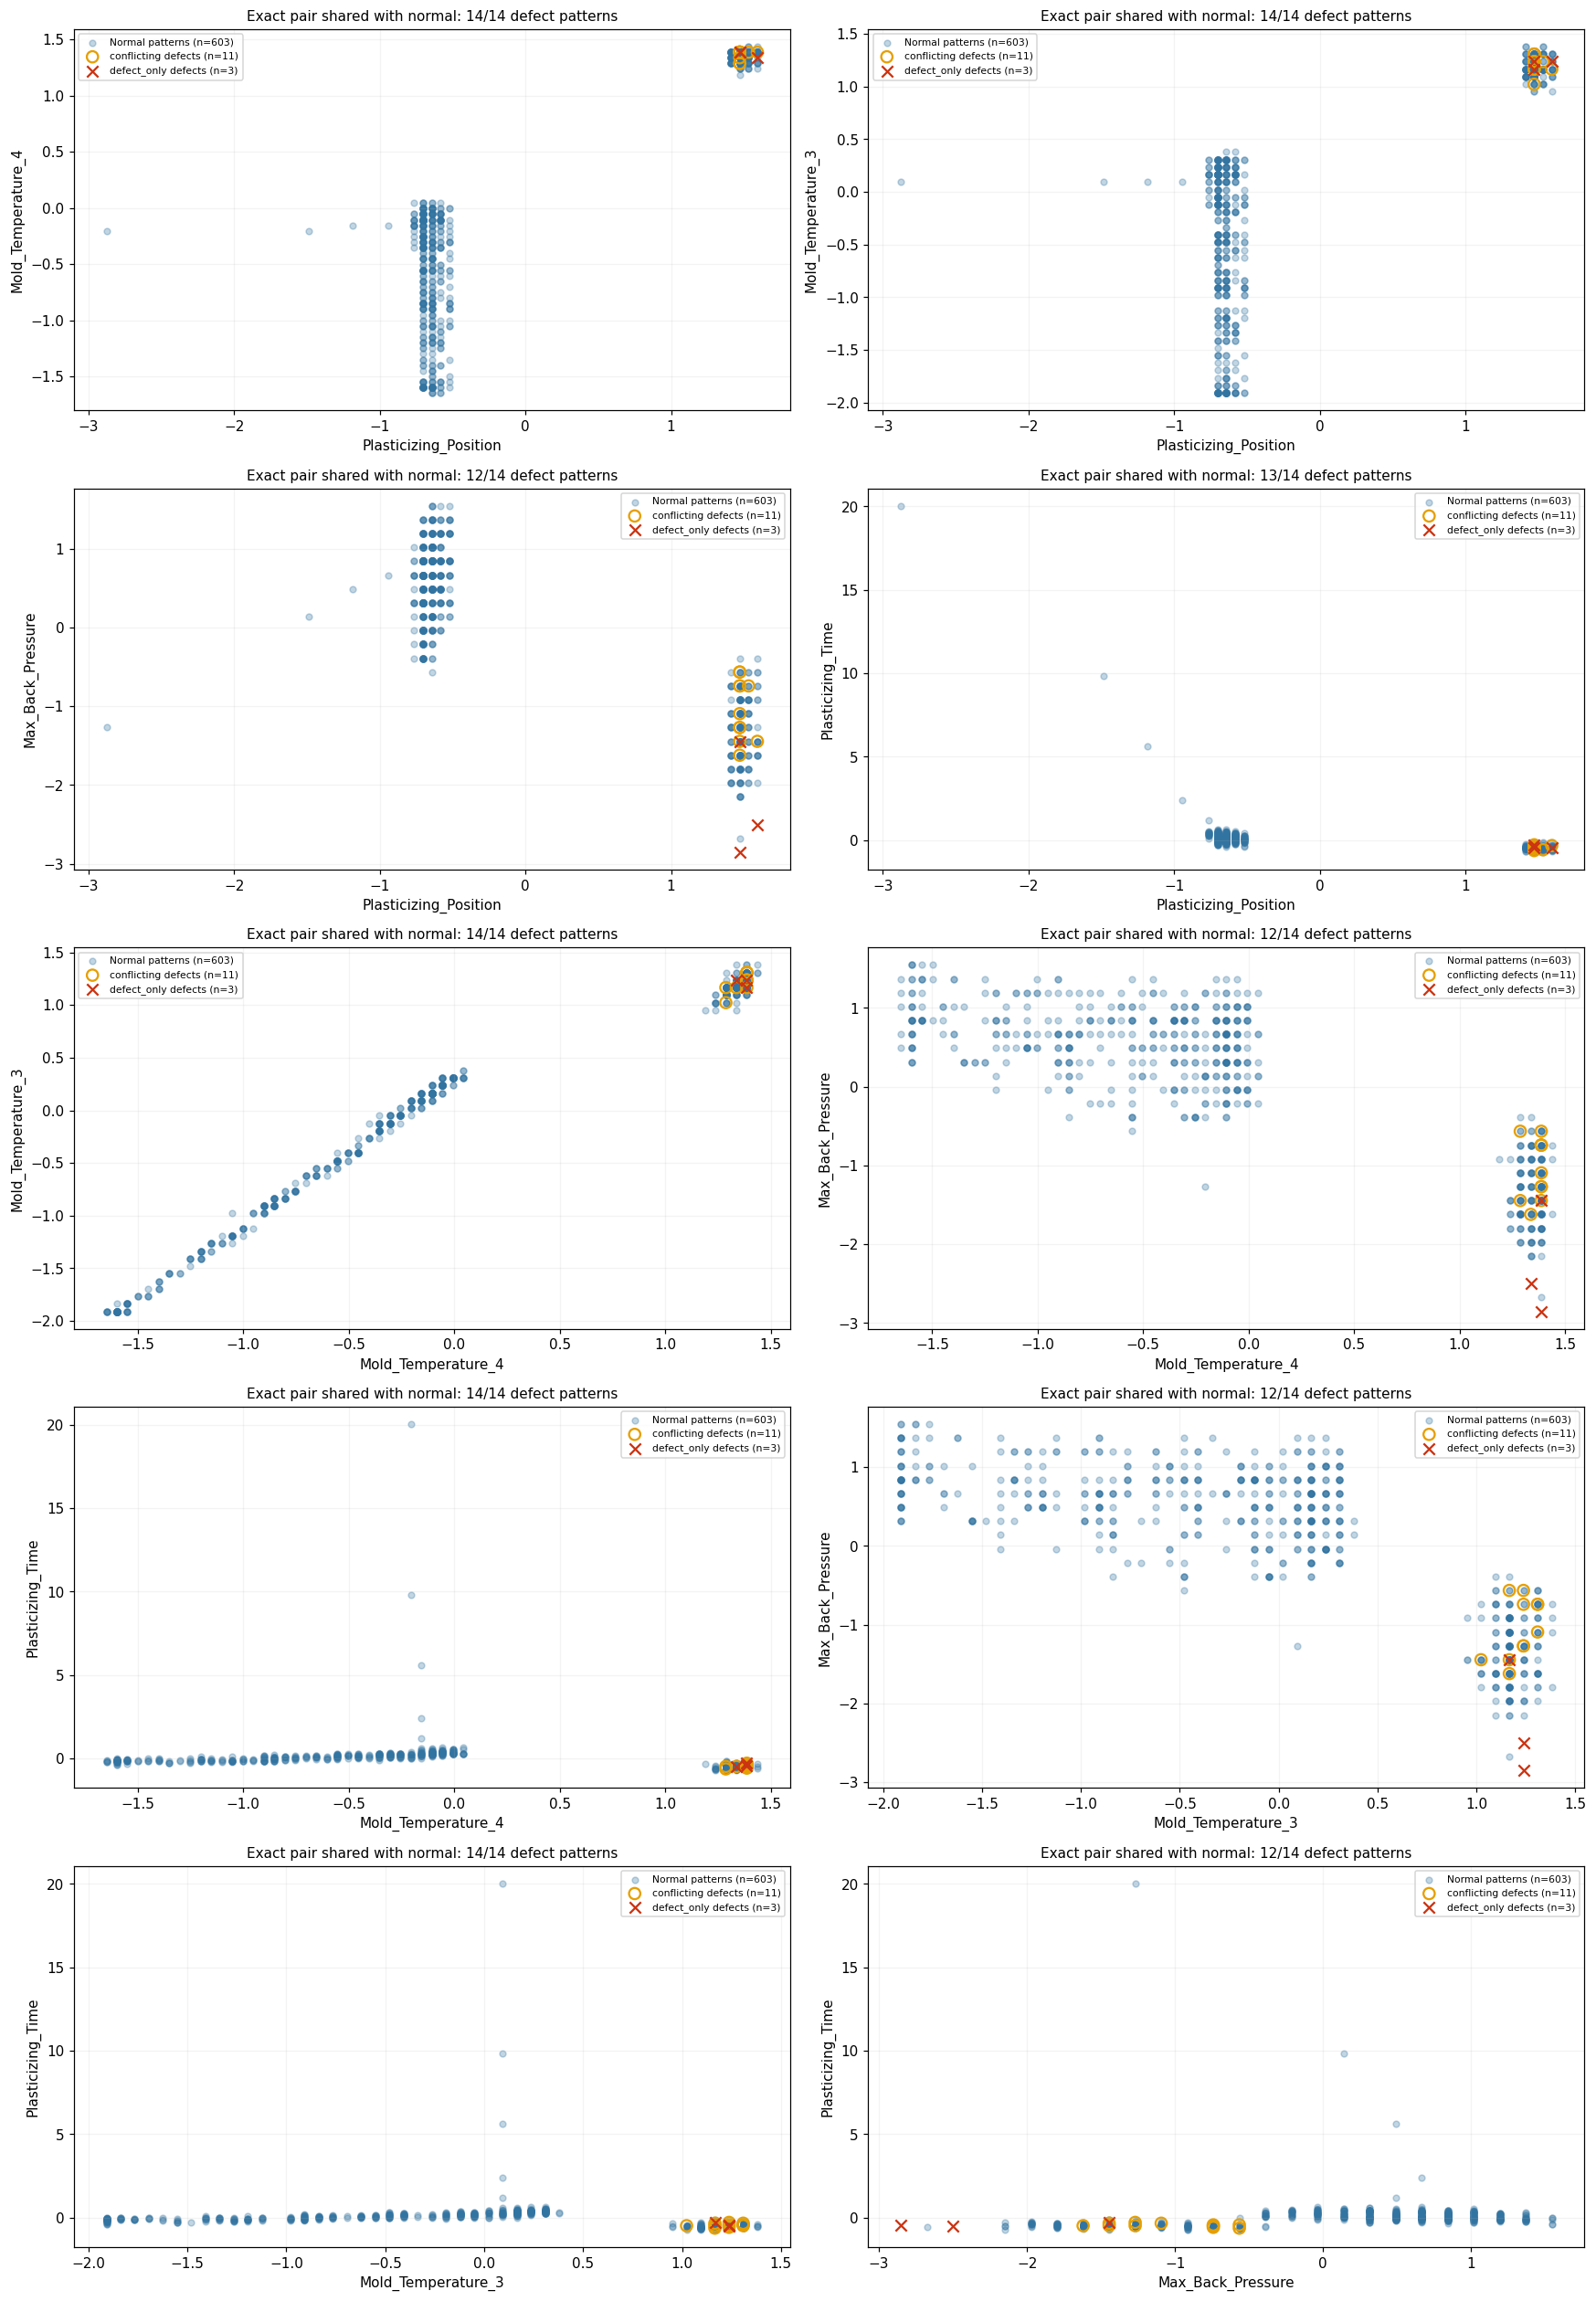

,feature_1,feature_2,normal_pattern_spearman,defect_patterns,shared_with_normal,no_exact_normal_pair
0,Plasticizing_Position,Mold_Temperature_4,0.596,14,14,0
1,Plasticizing_Position,Mold_Temperature_3,0.596,14,14,0
2,Plasticizing_Position,Max_Back_Pressure,-0.558,14,12,2
3,Plasticizing_Position,Plasticizing_Time,-0.736,14,13,1
4,Mold_Temperature_4,Mold_Temperature_3,0.988,14,14,0
5,Mold_Temperature_4,Max_Back_Pressure,-0.730,14,12,2
6,Mold_Temperature_4,Plasticizing_Time,-0.337,14,14,0
7,Mold_Temperature_3,Max_Back_Pressure,-0.730,14,12,2
8,Mold_Temperature_3,Plasticizing_Time,-0.333,14,14,0
9,Max_Back_Pressure,Plasticizing_Time,0.509,14,12,2


feature_1                      Plasticizing_Position  ... Max_Back_Pressure
feature_2                         Mold_Temperature_4  ... Plasticizing_Time
representative_id pattern_type                        ...                  
47                conflicting                     46  ...                 5
80                conflicting                     86  ...                 3
95                conflicting                     86  ...                 5
99                conflicting                     86  ...                 5
101               conflicting                     86  ...                 1
103               conflicting                     15  ...                13
105               conflicting                     86  ...                 9
107               conflicting                     61  ...                15
109               conflicting                     46  ...                13
111               conflicting                     21  ...                 1
113               conflicting                     86  ...                 3
115               defect_only                     86  ...                 2
117               defect_only                     86  ...                 0
119               defect_only                      2  ...                 0

[14 rows x 10 columns]

**겹침과 중복 정보:** 아래 표는 양품 고유 패턴에서 |Spearman|≥0.8인 쌍이다. 0.8은 관계를 요약하기 위한 표시 기준이다. 높은 상관은 두 변수가 비슷한 순서 정보를 가질 수 있음을 뜻하며, 독립적인 불량 요인 두 개를 발견했다는 의미는 아니다.

,feature_1,feature_2,normal_pattern_spearman
4,Mold_Temperature_4,Mold_Temperature_3,0.988


10개 쌍에서 동일 조합의 양품이 존재하는 불량 패턴 수는 12–14/14개다. 전체입력이 같은 충돌 패턴은 어느 변수 쌍에서도 분리할 수 없다. 쌍별 차이는 비충돌 불량을 중심으로 해석한다.

In [20]:
eda3_pair_rows = []
eda3_pair_details = []
fig, axes = plt.subplots(5, 2, figsize=(16,23))
for ax, (x,y) in zip(axes.flat, combinations(eda3_top5, 2)):
    eda3_scatter(ax, x, y)
    freq = eda3_normal.groupby([x,y]).size()
    counts = np.array([freq.get(tuple(v),0) for v in eda3_bad_unique[[x,y]].to_numpy()])
    eda3_pair_rows.append([x,y,eda3_normal_unique[[x,y]].corr(method='spearman').iloc[0,1],
                           len(counts),int((counts>0).sum()),int((counts==0).sum())])
    for (_,r), count in zip(eda3_bad_unique.iterrows(), counts):
        eda3_pair_details.append([x,y,int(r.source_id),int(r.pattern_id),r.pattern_type,int(count),
                                  int(eda3_patterns.loc[r.pattern_id,'defects'])])
    ax.set_title(f'Exact pair shared with normal: {(counts>0).sum()}/{len(counts)} defect patterns', fontsize=10)
plt.tight_layout(); plt.show()
eda3_pair_summary = pd.DataFrame(eda3_pair_rows, columns=[
    'feature_1','feature_2','normal_pattern_spearman','defect_patterns','shared_with_normal','no_exact_normal_pair'])
eda3_pair_detail = pd.DataFrame(eda3_pair_details, columns=[
    'feature_1','feature_2','representative_id','pattern_id','pattern_type','normal_rows_matching_pair','defect_rows_in_pattern'])
display(eda3_pair_summary.round(3))
display(eda3_pair_detail.pivot(index=['representative_id','pattern_type'], columns=['feature_1','feature_2'], values='normal_rows_matching_pair'))
eda3_strong = eda3_pair_summary.loc[eda3_pair_summary.normal_pattern_spearman.abs().ge(.8), ['feature_1','feature_2','normal_pattern_spearman']]
eda3_say('**겹침과 중복 정보:** 아래 표는 양품 고유 패턴에서 |Spearman|≥0.8인 쌍이다. '
         '0.8은 관계를 요약하기 위한 표시 기준이다. 높은 상관은 두 변수가 비슷한 순서 정보를 가질 수 있음을 뜻하며, 독립적인 불량 요인 두 개를 발견했다는 의미는 아니다.')
display(eda3_strong.round(3))
eda3_say(f'10개 쌍에서 동일 조합의 양품이 존재하는 불량 패턴 수는 '
         f'{eda3_pair_summary.shared_with_normal.min()}–{eda3_pair_summary.shared_with_normal.max()}/{len(eda3_bad_unique)}개다. '
         '전체입력이 같은 충돌 패턴은 어느 변수 쌍에서도 분리할 수 없다. 쌍별 차이는 비충돌 불량을 중심으로 해석한다.')

### 두 변수 구간별 관측 건수
양품 원본의 중앙값을 경계로 각 쌍을 네 구간으로 나눈다. 경계와 같은 값은 `≤ median`에 포함한다. 이산값·동률 때문에 구간 크기가 같지 않을 수 있다. 각 칸의 **불량 행/전체 행, 전체입력 패턴 수**를 함께 표시한다. 중앙값은 탐색용 구분이며 최적 불량 임계값이 아니다. 원본 중복을 유지한 관측 비율이고 독립 표본 기반 확률 추정은 아니다.

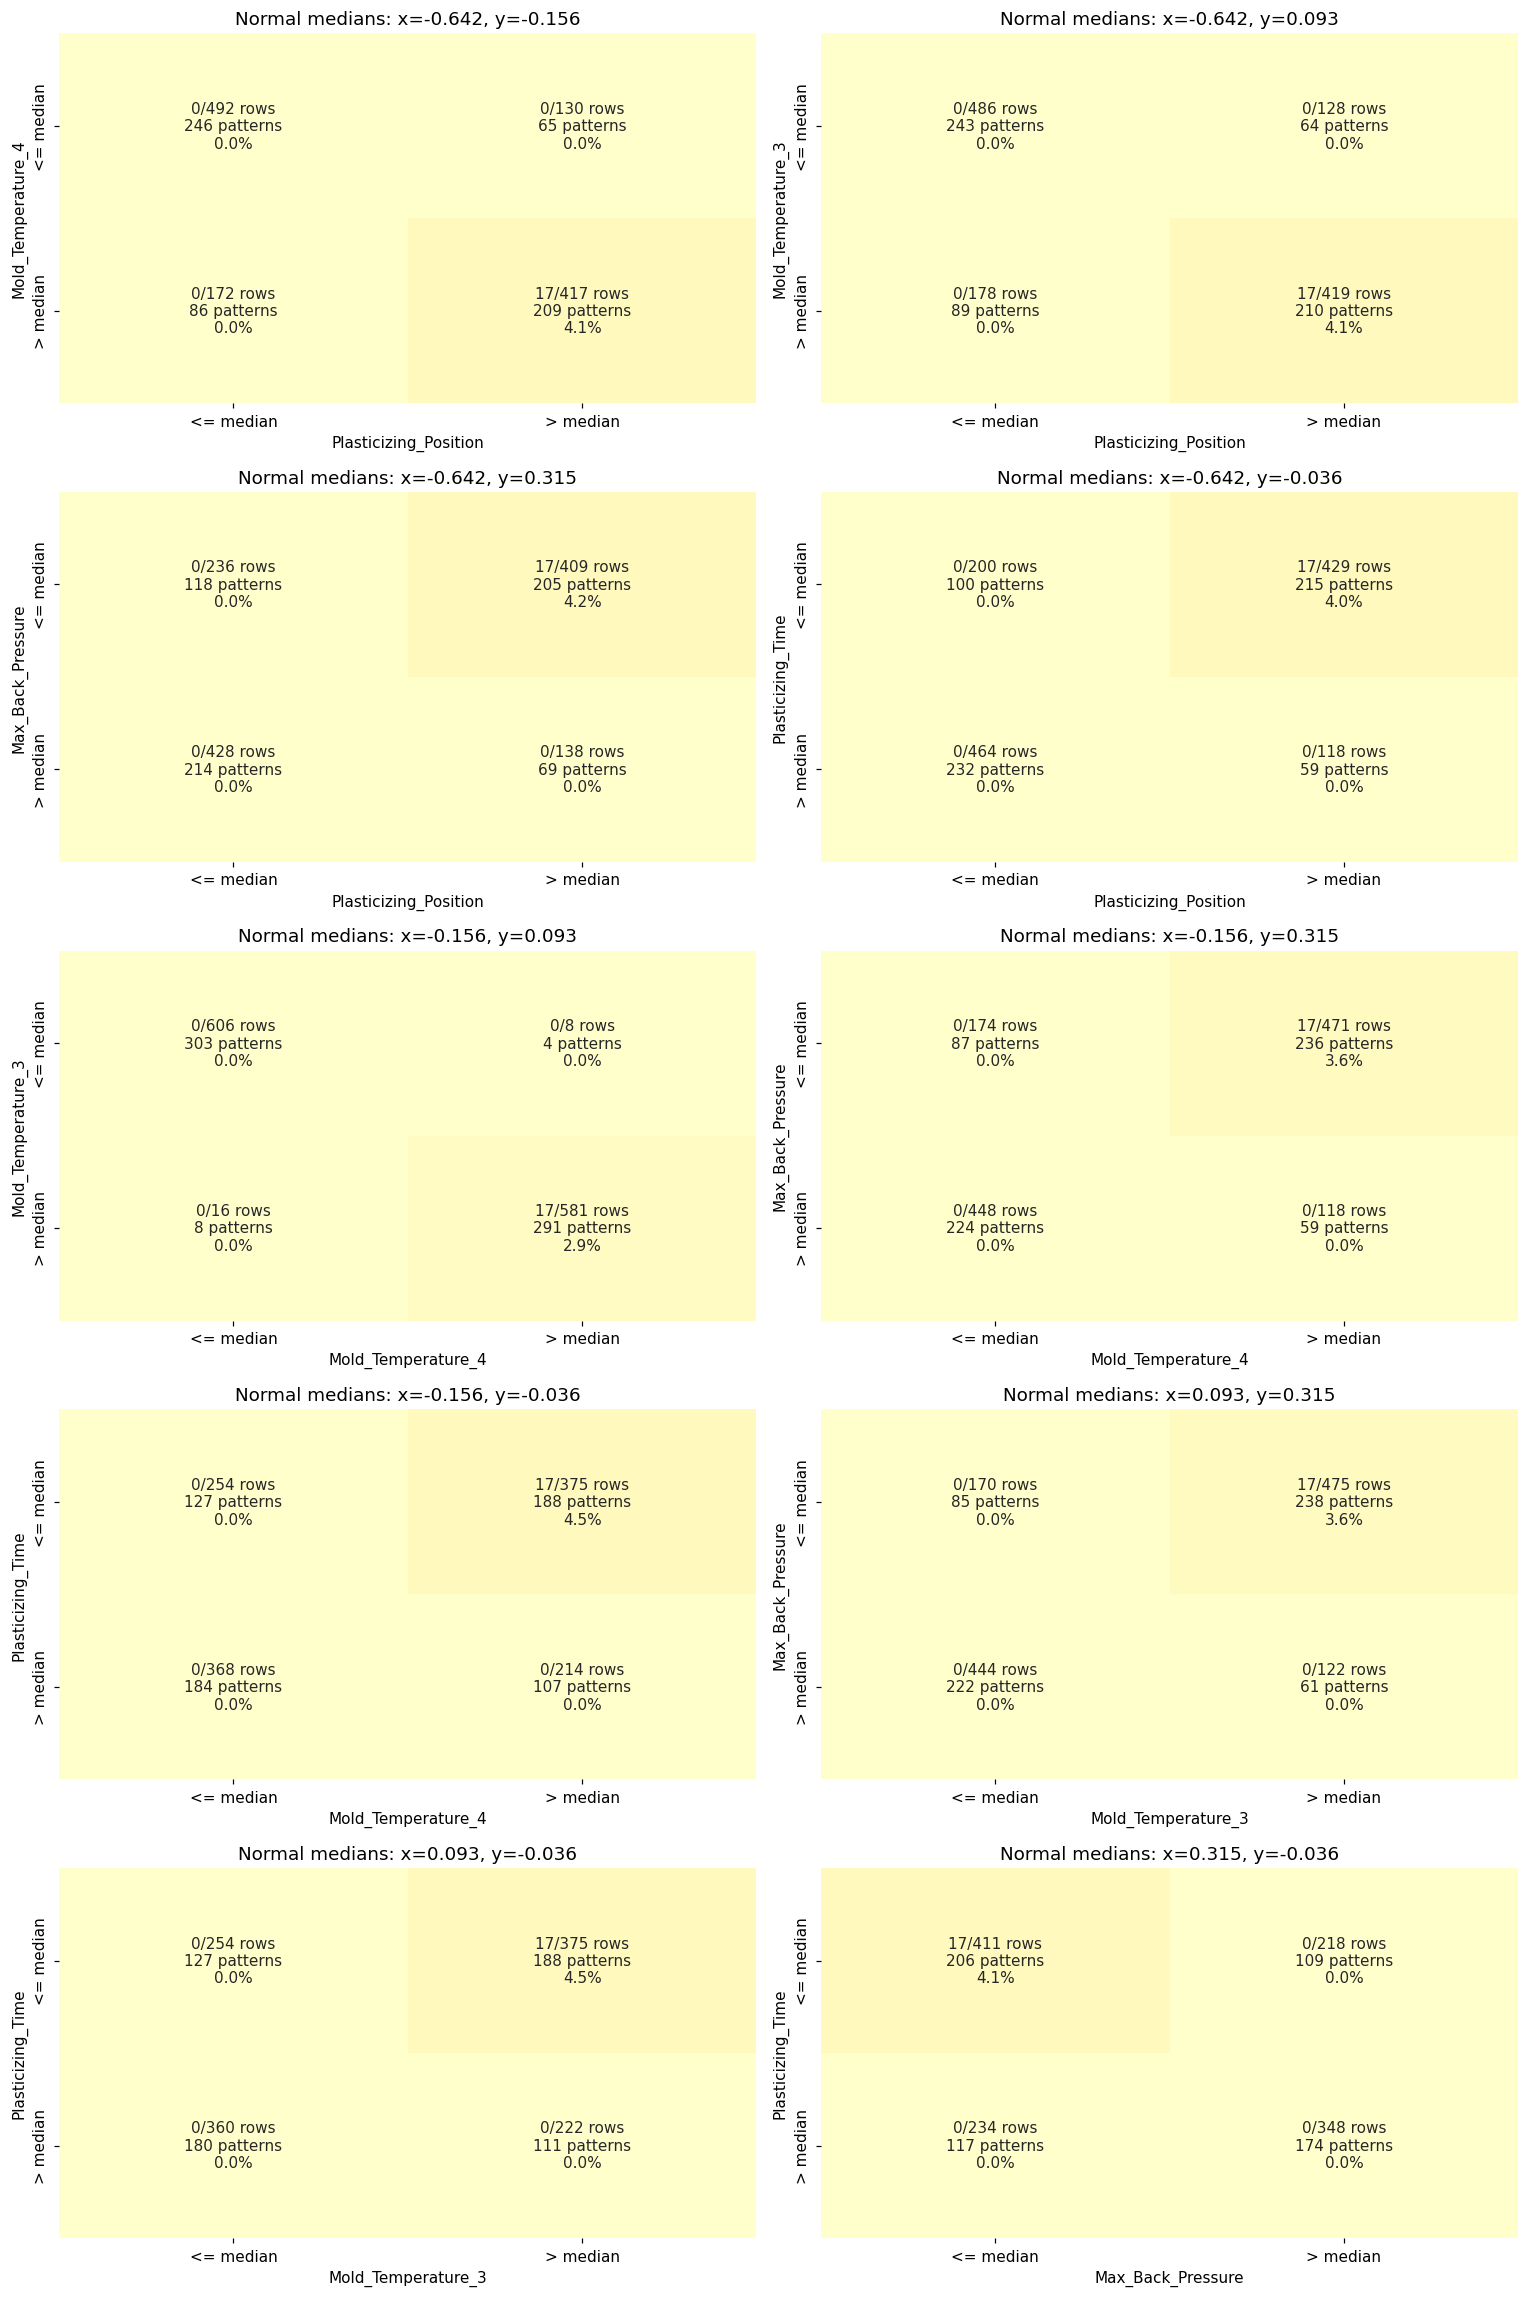

,feature_1,feature_2,x_cut,y_cut,x_high,y_high,rows,defects,patterns,observed_defect_fraction
0,Plasticizing_Position,Mold_Temperature_4,-0.642290,-0.155625,0,0,492,0,246,0.000000
1,Plasticizing_Position,Mold_Temperature_4,-0.642290,-0.155625,1,0,130,0,65,0.000000
2,Plasticizing_Position,Mold_Temperature_4,-0.642290,-0.155625,0,1,172,0,86,0.000000
3,Plasticizing_Position,Mold_Temperature_4,-0.642290,-0.155625,1,1,417,17,209,0.040767
4,Plasticizing_Position,Mold_Temperature_3,-0.642290,0.093154,0,0,486,0,243,0.000000
5,Plasticizing_Position,Mold_Temperature_3,-0.642290,0.093154,1,0,128,0,64,0.000000
6,Plasticizing_Position,Mold_Temperature_3,-0.642290,0.093154,0,1,178,0,89,0.000000
7,Plasticizing_Position,Mold_Temperature_3,-0.642290,0.093154,1,1,419,17,210,0.040573
8,Plasticizing_Position,Max_Back_Pressure,-0.642290,0.314806,0,0,236,0,118,0.000000
9,Plasticizing_Position,Max_Back_Pressure,-0.642290,0.314806,1,0,409,17,205,0.041565


**해석:** 같은 색의 차이도 분모와 고유 패턴 수를 먼저 확인한다. 불량이 포함된 구간에 양품도 많다면 그 조합은 점검할 조건을 설명하지만 단독 판정 규칙으로는 부족하다. KS 상위 변수 선정과 이 구간 비교는 같은 데이터를 사용했으므로 독립 검증이 아니다.

In [21]:
eda3_quadrants = []
fig, axes = plt.subplots(5,2,figsize=(14,21))
for ax,(x,y) in zip(axes.flat, combinations(eda3_top5,2)):
    mx,my = eda3_normal[x].median(),eda3_normal[y].median()
    rates = np.full((2,2),np.nan); labels = np.empty((2,2),dtype=object)
    for iy in range(2):
        for ix in range(2):
            mask = (eda3_raw[x].gt(mx) if ix else eda3_raw[x].le(mx)) & (eda3_raw[y].gt(my) if iy else eda3_raw[y].le(my))
            g=eda3_raw.loc[mask]; total=len(g); bad=int(g.PassOrFail.sum()); patterns=g.pattern_id.nunique()
            rate=bad/total if total else np.nan
            rates[iy,ix]=100*rate
            labels[iy,ix]=f'{bad}/{total} rows\n{patterns} patterns\n{100*rate:.1f}%' if total else 'No observations'
            eda3_quadrants.append([x,y,mx,my,ix,iy,total,bad,patterns,rate])
    sns.heatmap(rates,annot=labels,fmt='',cmap='YlOrRd',vmin=0,vmax=100,cbar=False,ax=ax,
                xticklabels=['<= median','> median'],yticklabels=['<= median','> median'])
    for iy,ix in zip(*np.where(np.isnan(rates))):ax.text(ix+.5,iy+.5,'No observations',ha='center',va='center',fontsize=9)
    ax.set(xlabel=x,ylabel=y,title=f'Normal medians: x={mx:.3f}, y={my:.3f}')
plt.tight_layout();plt.show()
eda3_quadrant_table=pd.DataFrame(eda3_quadrants,columns=['feature_1','feature_2','x_cut','y_cut','x_high','y_high','rows','defects','patterns','observed_defect_fraction'])
display(eda3_quadrant_table)
eda3_say('**해석:** 같은 색의 차이도 분모와 고유 패턴 수를 먼저 확인한다. '
         '불량이 포함된 구간에 양품도 많다면 그 조합은 점검할 조건을 설명하지만 단독 판정 규칙으로는 부족하다. '
         'KS 상위 변수 선정과 이 구간 비교는 같은 데이터를 사용했으므로 독립 검증이 아니다.')

## 3.3 상위 변수의 개별 분포와 사례 의존성 ②
**질문:** 기존 KS 상위 변수의 차이는 원본에서도 나타나며, 특이 불량 3개 패턴을 제외해도 남는가?

같은 5개 변수를 유지하고 다음 KS를 비교한다: 원본 행, 기존 불량 우선 중복 처리, 라벨별 고유 패턴, 원본 양품 대비 충돌 불량만, 원본 양품 대비 비충돌 불량만. 마지막 두 비교는 불량 유형의 특성을 보기 위한 것이며 성능 평가가 아니다. 모든 유형 비교에서 양품 참조집합을 동일하게 유지한다.

,view,feature,normal_n,defect_n,KS,normal_median,defect_median
0,Original rows,Plasticizing_Position,1194,17,0.752094,-0.642290,1.471608
1,Original rows,Mold_Temperature_4,1194,17,0.715243,-0.155625,1.387105
2,Original rows,Mold_Temperature_3,1194,17,0.706671,0.093154,1.237697
3,Original rows,Max_Back_Pressure,1194,17,0.700168,0.314806,-1.444462
4,Original rows,Plasticizing_Time,1194,17,0.695142,-0.036274,-0.428933
5,Existing defect-priority,Plasticizing_Position,592,14,0.758446,-0.642290,1.471608
6,Existing defect-priority,Mold_Temperature_4,592,14,0.721284,-0.155625,1.387105
7,Existing defect-priority,Mold_Temperature_3,592,14,0.711149,0.093154,1.237697
8,Existing defect-priority,Max_Back_Pressure,592,14,0.706081,0.314806,-1.268531
9,Existing defect-priority,Plasticizing_Time,592,14,0.701014,-0.036274,-0.453475


view,Conflicting defects only,Defect-only patterns only,Existing defect-priority,Original rows,Unique within label
feature,,,,,
Plasticizing_Position,0.752,0.752,0.758,0.752,0.745
Mold_Temperature_4,0.715,0.785,0.721,0.715,0.708
Mold_Temperature_3,0.705,0.765,0.711,0.707,0.698
Max_Back_Pressure,0.700,0.853,0.706,0.700,0.693
Plasticizing_Time,0.695,0.695,0.701,0.695,0.688


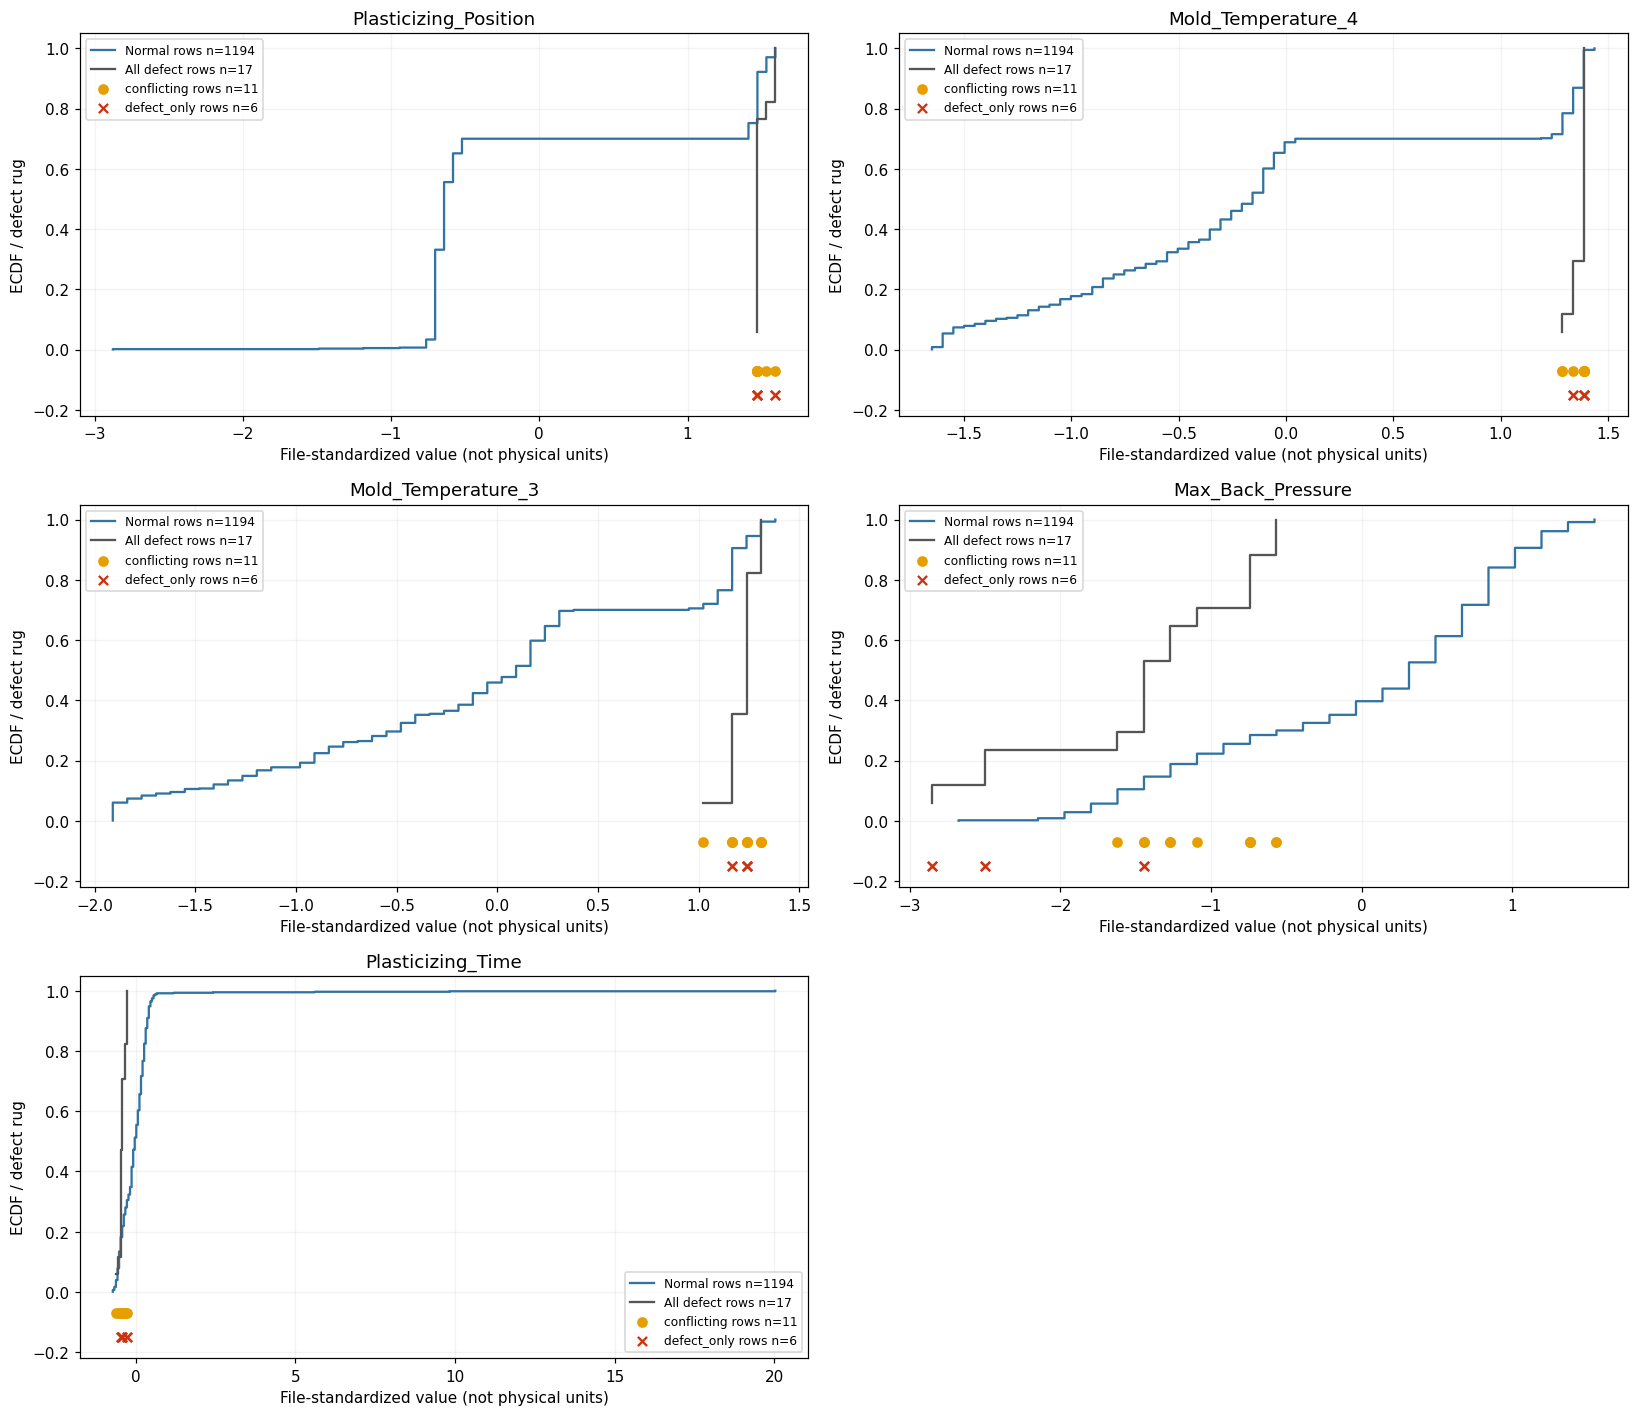

,feature,value,normal_rows,defect_rows,normal_patterns,defect_patterns,defect_IDs,observed_defect_fraction_at_value
0,Plasticizing_Position,1.471608,203,13,106,11,"[47, 80, 95, 99, 101, 105, 107, 109, 113, 115,...",0.060185
1,Plasticizing_Position,1.532018,58,1,30,1,[103],0.016949
2,Plasticizing_Position,1.592429,35,3,18,2,"[111, 119, 120]",0.078947
3,Mold_Temperature_4,1.287574,83,2,43,2,"[47, 109]",0.023529
4,Mold_Temperature_4,1.337339,101,3,51,2,"[107, 119, 120]",0.028846
5,Mold_Temperature_4,1.387105,150,12,79,10,"[80, 95, 99, 101, 103, 105, 111, 113, 115, 116...",0.074074
6,Mold_Temperature_3,1.023094,18,1,10,1,[109],0.052632
7,Mold_Temperature_3,1.166162,167,5,85,4,"[47, 107, 111, 115, 116]",0.029070
8,Mold_Temperature_3,1.237697,48,8,26,6,"[99, 103, 105, 113, 117, 118, 119, 120]",0.142857
9,Mold_Temperature_3,1.309231,57,3,30,3,"[80, 95, 101]",0.050000


**특이 3개 패턴 제외 후의 결과:**

- Plasticizing_Position: 원본 KS **0.752**, 충돌 불량만 **0.752**, 비충돌 불량만 **0.752**. 크기 차이는 유형별 분포 차이이며 독립적인 예측력 차이가 아니다.

- Mold_Temperature_4: 원본 KS **0.715**, 충돌 불량만 **0.715**, 비충돌 불량만 **0.785**. 크기 차이는 유형별 분포 차이이며 독립적인 예측력 차이가 아니다.

- Mold_Temperature_3: 원본 KS **0.707**, 충돌 불량만 **0.705**, 비충돌 불량만 **0.765**. 크기 차이는 유형별 분포 차이이며 독립적인 예측력 차이가 아니다.

- Max_Back_Pressure: 원본 KS **0.700**, 충돌 불량만 **0.700**, 비충돌 불량만 **0.853**. 크기 차이는 유형별 분포 차이이며 독립적인 예측력 차이가 아니다.

- Plasticizing_Time: 원본 KS **0.695**, 충돌 불량만 **0.695**, 비충돌 불량만 **0.695**. 크기 차이는 유형별 분포 차이이며 독립적인 예측력 차이가 아니다.

양품과 같은 입력을 가진 불량만 남겨도 KS가 0일 필요는 없다. 충돌 불량은 전체 양품 중 특정 조건에 집중된 일부이므로 빈도 분포는 다를 수 있다. 따라서 큰 KS와 동일 입력의 라벨 충돌은 동시에 존재할 수 있다.

In [22]:
eda3_ks_rows=[]
eda3_views={
    'Original rows':(eda3_normal,eda3_bad),
    'Existing defect-priority':(eda3_current[eda3_current.PassOrFail.eq(0)],eda3_current[eda3_current.PassOrFail.eq(1)]),
    'Unique within label':(eda3_normal_unique,eda3_bad_unique),
    'Conflicting defects only':(eda3_normal,eda3_bad[eda3_bad.pattern_type.eq('conflicting')]),
    'Defect-only patterns only':(eda3_normal,eda3_bad[eda3_bad.pattern_type.eq('defect_only')])}
for view,(normal,bad) in eda3_views.items():
    for c in eda3_top5:
        eda3_ks_rows.append([view,c,len(normal),len(bad),ks_2samp(normal[c],bad[c]).statistic,
                             normal[c].median(),bad[c].median()])
eda3_ks_sensitivity=pd.DataFrame(eda3_ks_rows,columns=['view','feature','normal_n','defect_n','KS','normal_median','defect_median'])
display(eda3_ks_sensitivity)
eda3_ks_wide=eda3_ks_sensitivity.pivot(index='feature',columns='view',values='KS').reindex(eda3_top5)
display(eda3_ks_wide.round(3))
assert np.allclose(eda3_ks_wide['Existing defect-priority'],ks_df.set_index('Feature').loc[eda3_top5,'KS_Statistic'])
fig,axes=plt.subplots(3,2,figsize=(15,13))
for ax,c in zip(axes.flat,eda3_top5):
    for label,g,color in [('Normal rows',eda3_normal,'#3274A1'),('All defect rows',eda3_bad,'#555555')]:
        v=np.sort(g[c].to_numpy());ax.step(v,np.arange(1,len(v)+1)/len(v),where='post',label=f'{label} n={len(v)}',color=color)
    for kind,level,marker in [('conflicting',-.07,'o'),('defect_only',-.15,'x')]:
        g=eda3_bad[eda3_bad.pattern_type.eq(kind)]
        ax.scatter(g[c],np.full(len(g),level),color=eda3_colors[kind],marker=marker,label=f'{kind} rows n={len(g)}')
    ax.set(title=c,xlabel='File-standardized value (not physical units)',ylabel='ECDF / defect rug',ylim=(-.22,1.05))
    ax.legend(fontsize=8);ax.grid(alpha=.15)
axes.flat[-1].axis('off');plt.tight_layout();plt.show()

# 불량에서 관측된 실제 값별로 양품 빈도와 고유 전체입력 패턴 수를 표시한다.
eda3_value_rows=[]
for c in eda3_top5:
    for value,b in eda3_bad.groupby(c):
        a=eda3_normal[eda3_normal[c].eq(value)]
        eda3_value_rows.append([c,value,len(a),len(b),a.pattern_id.nunique(),b.pattern_id.nunique(),b.source_id.tolist(),len(b)/(len(a)+len(b))])
eda3_value_table=pd.DataFrame(eda3_value_rows,columns=['feature','value','normal_rows','defect_rows','normal_patterns','defect_patterns','defect_IDs','observed_defect_fraction_at_value'])
display(eda3_value_table)
eda3_say('**특이 3개 패턴 제외 후의 결과:**')
for c in eda3_top5:
    r=eda3_ks_wide.loc[c]
    eda3_say(f'- {c}: 원본 KS **{r["Original rows"]:.3f}**, 충돌 불량만 **{r["Conflicting defects only"]:.3f}**, '
             f'비충돌 불량만 **{r["Defect-only patterns only"]:.3f}**. '
             '크기 차이는 유형별 분포 차이이며 독립적인 예측력 차이가 아니다.')
eda3_say('양품과 같은 입력을 가진 불량만 남겨도 KS가 0일 필요는 없다. '
         '충돌 불량은 전체 양품 중 특정 조건에 집중된 일부이므로 빈도 분포는 다를 수 있다. '
         '따라서 큰 KS와 동일 입력의 라벨 충돌은 동시에 존재할 수 있다.')

## 3.4 공정 단계별 조합 비교 ④
**질문:** KS 상위 변수의 관찰은 충전·사출·보압 관련 공정값과 어떻게 연결되는가?

충전시간–최대사출속도, 사출시간–최대사출압력, 전환압력–쿠션위치에 더해, 상위 5개에 포함된 계량위치–배압·계량시간을 비교한다. `Injection_Time`과 최대사출압력은 사출 공통 요약값이며 가압 단계만의 측정값이 아니다. 전환압력과 쿠션 위치만으로 보압 유지 전체를 관측할 수 없다. `Mold_Temperature_3/4`는 가이드북의 이름과 설명이 불일치하므로 열적 조건 참고로만 남긴다.

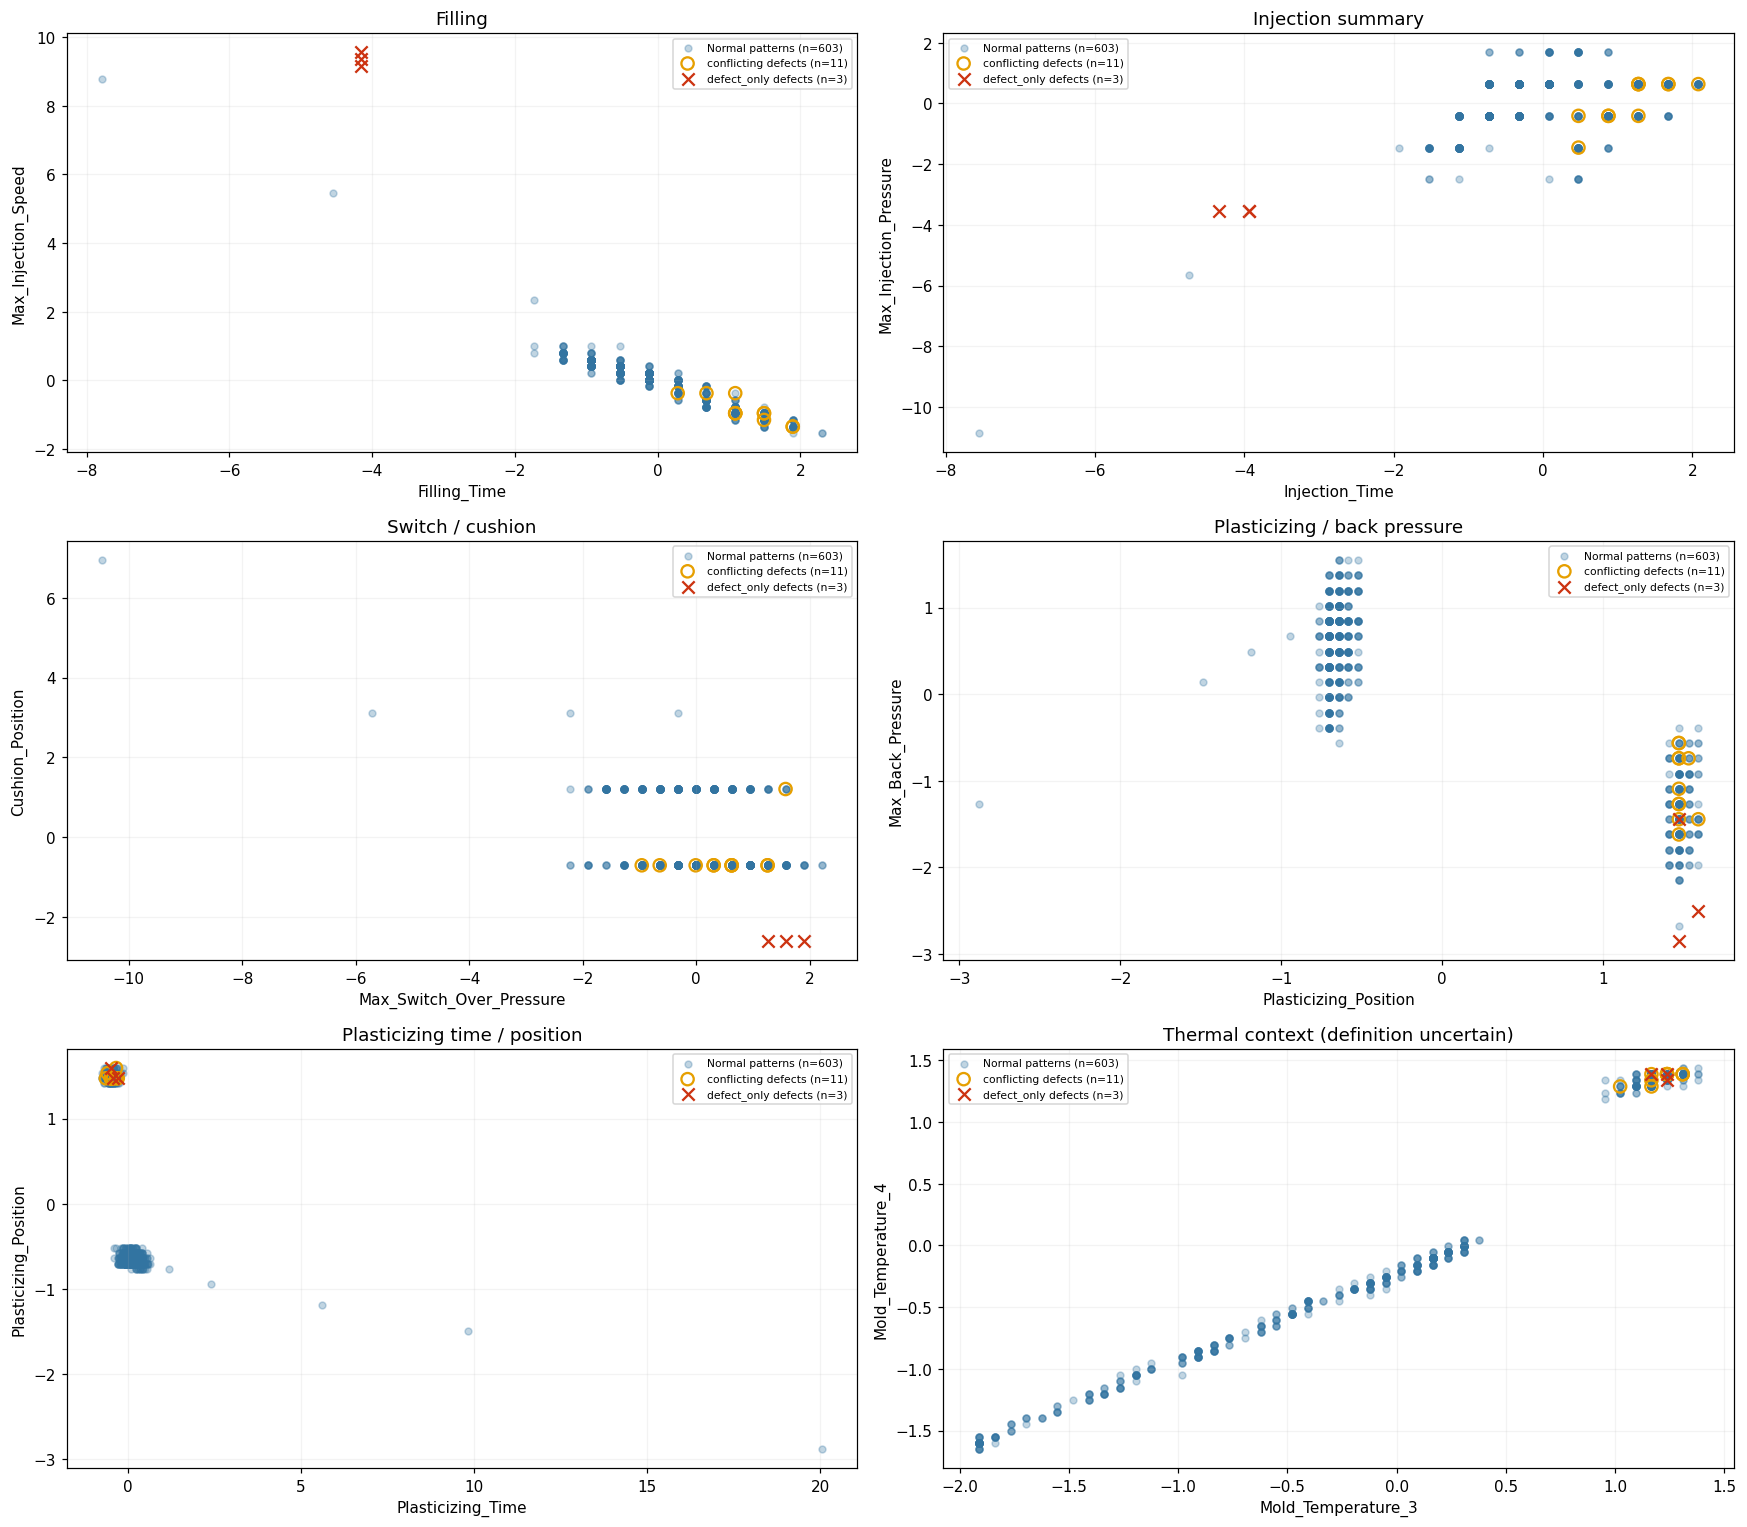

defect_patterns  ...  y_outside
stage                                  type                          ...           
Filling                                conflicting               11  ...          0
                                       defect_only                3  ...          3
Injection summary                      conflicting               11  ...          0
                                       defect_only                3  ...          0
Plasticizing / back pressure           conflicting               11  ...          0
                                       defect_only                3  ...          1
Plasticizing time / position           conflicting               11  ...          0
                                       defect_only                3  ...          0
Switch / cushion                       conflicting               11  ...          0
                                       defect_only                3  ...          3
Thermal context (definition uncertain) conflicting               11  ...          0
                                       defect_only                3  ...          0

[12 rows x 4 columns]

,stage,representative_id,pattern_id,type,normal_rows_matching_pair,x_outside_observed_normal_range,y_outside_observed_normal_range
11,Filling,115,58,defect_only,0,False,True
12,Filling,117,59,defect_only,0,False,True
13,Filling,119,60,defect_only,0,False,True
25,Injection summary,115,58,defect_only,0,False,False
26,Injection summary,117,59,defect_only,0,False,False
27,Injection summary,119,60,defect_only,0,False,False
39,Switch / cushion,115,58,defect_only,0,False,True
40,Switch / cushion,117,59,defect_only,0,False,True
41,Switch / cushion,119,60,defect_only,0,False,True
53,Plasticizing / back pressure,115,58,defect_only,29,False,False


**공정별 결과 — 비충돌 불량 고유 패턴 기준:**

- Filling: 3개 중 0개는 같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 3개.

- Injection summary: 3개 중 0개는 같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Switch / cushion: 3개 중 0개는 같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 3개.

- Plasticizing / back pressure: 3개 중 1개는 같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 1개.

- Plasticizing time / position: 3개 중 2개는 같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

- Thermal context (definition uncertain): 3개 중 3개는 같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 0개, y 범위 밖 0개.

**종합:** KS 상위 변수는 불량이 집중된 조건의 분포를 설명하고, 공정별 조합은 일부 불량의 특이 조건을 설명한다. 충돌 불량은 현재 24개 값으로 양품과 구별할 수 없다는 한계가 남는다. 관측 범위 밖이라는 표현은 제조 규격 초과가 아니며, 변수 간 동반 변화로 공정 원인이나 이상 전파를 확정하지 않는다.

In [23]:
eda3_process_pairs=[
    ('Filling','Filling_Time','Max_Injection_Speed'),
    ('Injection summary','Injection_Time','Max_Injection_Pressure'),
    ('Switch / cushion','Max_Switch_Over_Pressure','Cushion_Position'),
    ('Plasticizing / back pressure','Plasticizing_Position','Max_Back_Pressure'),
    ('Plasticizing time / position','Plasticizing_Time','Plasticizing_Position'),
    ('Thermal context (definition uncertain)','Mold_Temperature_3','Mold_Temperature_4')]
eda3_process_rows=[]
fig,axes=plt.subplots(3,2,figsize=(16,14))
for ax,(stage,x,y) in zip(axes.flat,eda3_process_pairs):
    eda3_scatter(ax,x,y);ax.set_title(stage)
    freq=eda3_normal.groupby([x,y]).size()
    for _,r in eda3_bad_unique.iterrows():
        eda3_process_rows.append([stage,int(r.source_id),int(r.pattern_id),r.pattern_type,
            int(freq.get((r[x],r[y]),0)),
            bool(r[x]<eda3_normal[x].min() or r[x]>eda3_normal[x].max()),
            bool(r[y]<eda3_normal[y].min() or r[y]>eda3_normal[y].max())])
plt.tight_layout();plt.show()
eda3_process_detail=pd.DataFrame(eda3_process_rows,columns=['stage','representative_id','pattern_id','type','normal_rows_matching_pair','x_outside_observed_normal_range','y_outside_observed_normal_range'])
eda3_process_summary=eda3_process_detail.groupby(['stage','type']).agg(
    defect_patterns=('pattern_id','size'),pair_shared_with_normal=('normal_rows_matching_pair',lambda s:int(s.gt(0).sum())),
    x_outside=('x_outside_observed_normal_range','sum'),y_outside=('y_outside_observed_normal_range','sum'))
display(eda3_process_summary)
display(eda3_process_detail[eda3_process_detail['type'].eq('defect_only')])
eda3_say('**공정별 결과 — 비충돌 불량 고유 패턴 기준:**')
for stage,_,_ in eda3_process_pairs:
    g=eda3_process_detail[(eda3_process_detail.stage.eq(stage)) & eda3_process_detail['type'].eq('defect_only')]
    eda3_say(f'- {stage}: {len(g)}개 중 {g.normal_rows_matching_pair.gt(0).sum()}개는 '
             f'같은 2변수 조합의 양품이 있다. x 관측 양품 범위 밖 {g.x_outside_observed_normal_range.sum()}개, '
             f'y 범위 밖 {g.y_outside_observed_normal_range.sum()}개.')
eda3_say('**종합:** KS 상위 변수는 불량이 집중된 조건의 분포를 설명하고, 공정별 조합은 일부 불량의 특이 조건을 설명한다. '
         '충돌 불량은 현재 24개 값으로 양품과 구별할 수 없다는 한계가 남는다. '
         '관측 범위 밖이라는 표현은 제조 규격 초과가 아니며, 변수 간 동반 변화로 공정 원인이나 이상 전파를 확정하지 않는다.')